<a href="https://colab.research.google.com/github/Bachbean/Predicting-the-Unpredictable/blob/main/scripts/temp_iaaft_surrogate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Number of data points: 100000

REAL DATA
tau = 108
m = 3
Theiler window = 108
Largest Lyapunov exponent = 0.00196153
R^2 of fit = 0.987657


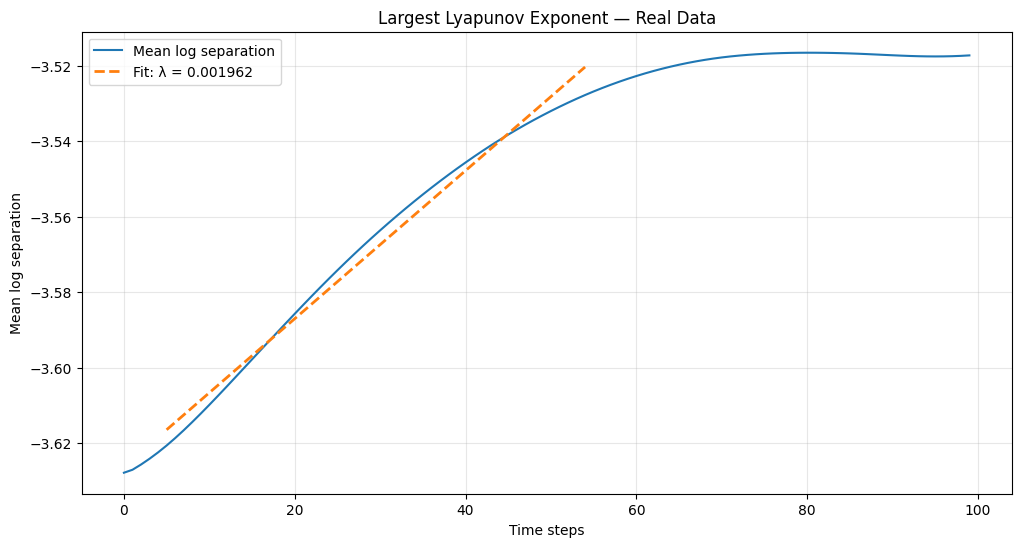


IAAFT SURROGATE TEST
Surrogate   1: lambda = 0.03031635, R² = 0.9118, spectral error = 6.505933e-05
Surrogate   2: lambda = 0.02974627, R² = 0.9109, spectral error = 6.646209e-05
Surrogate   3: lambda = 0.03008510, R² = 0.9113, spectral error = 7.118720e-05
Surrogate   4: lambda = 0.03024961, R² = 0.9037, spectral error = 6.964699e-05
Surrogate   5: lambda = 0.03049457, R² = 0.9084, spectral error = 7.146569e-05
Surrogate   6: lambda = 0.02992974, R² = 0.9094, spectral error = 7.395804e-05
Surrogate   7: lambda = 0.02994799, R² = 0.9064, spectral error = 7.010853e-05
Surrogate   8: lambda = 0.03024227, R² = 0.9100, spectral error = 6.596085e-05
Surrogate   9: lambda = 0.03059326, R² = 0.9082, spectral error = 7.323077e-05
Surrogate  10: lambda = 0.03008981, R² = 0.9102, spectral error = 7.044085e-05
Surrogate  11: lambda = 0.03003614, R² = 0.9113, spectral error = 7.105003e-05
Surrogate  12: lambda = 0.02926820, R² = 0.9165, spectral error = 9.484931e-05
Surrogate  13: lambda = 0.0298

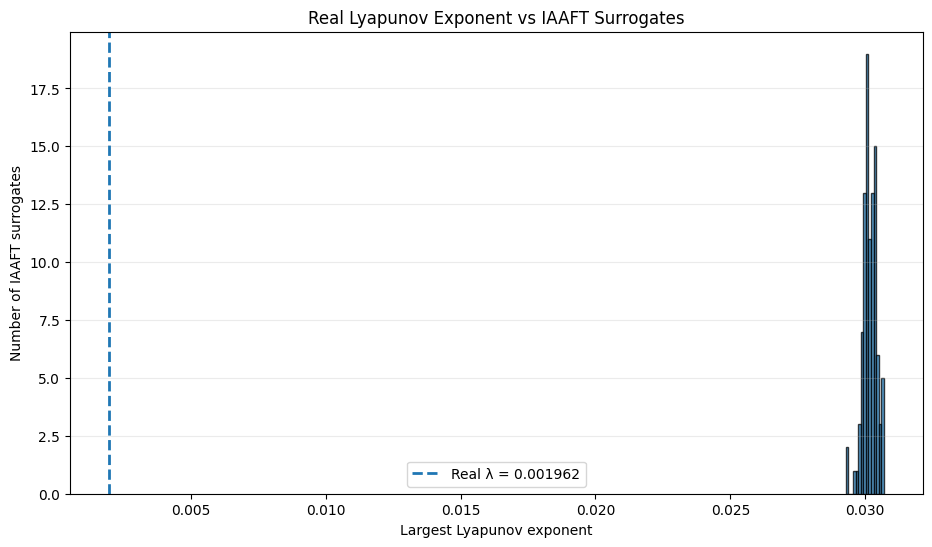


INTERPRETATION
The real Lyapunov exponent is not unusually large relative to the IAAFT surrogate distribution.
The current Lyapunov result therefore does not clearly distinguish the real data from this surrogate null model.

Important: rejection of the surrogate null is evidence of nonlinear temporal structure; it does not by itself prove deterministic chaos.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree


# ============================================================
# 1. LOAD DATA
# ============================================================

file_name = "https://raw.githubusercontent.com/Bachbean/Predicting-the-Unpredictable/refs/heads/main/scripts/temperature.txt"

data = np.loadtxt(file_name, dtype=np.float64)
data = np.asarray(data).squeeze()

if data.ndim != 1:
    raise ValueError("Data must be one-dimensional.")

if np.any(~np.isfinite(data)):
    raise ValueError("Data contains NaN or infinite values.")

print("Number of data points:", len(data))


# ============================================================
# 2. ANALYSIS SETTINGS
# ============================================================

# Based on your AMI analysis
tau = 108

# Based on your FNN analysis
m = 3

# Exclude temporally nearby points when finding neighbors
theiler_window = 108

# How far forward to track divergence
max_k = 100

# Region that you already found to be approximately linear
fit_start = 5
fit_end = 55

# If the sampling interval is unknown, leave this as 1.
# Then lambda is measured "per sample".
dt = 1.0


# ============================================================
# 3. DELAY EMBEDDING FUNCTION
# ============================================================

def delay_embed(data, m, tau):

    N = len(data) - (m - 1) * tau

    if N <= 0:
        raise ValueError("Embedding parameters are too large.")

    X = np.empty((N, m))

    for j in range(m):
        X[:, j] = data[
            j * tau : j * tau + N
        ]

    return X


# ============================================================
# 4. LARGEST LYAPUNOV EXPONENT FUNCTION
#    Rosenstein-style nearest-neighbor divergence
# ============================================================

def calculate_lyapunov(
    data,
    tau=108,
    m=3,
    theiler_window=108,
    max_k=100,
    fit_start=5,
    fit_end=55,
    dt=1.0,
    return_curve=False
):

    # --------------------------------------------------------
    # Reconstruct state space
    # --------------------------------------------------------

    X = delay_embed(data, m, tau)

    usable_points = len(X) - max_k

    if usable_points <= 10:
        raise ValueError("Not enough points for Lyapunov analysis.")

    X_search = X[:usable_points]


    # --------------------------------------------------------
    # Find spatial nearest neighbors
    # --------------------------------------------------------

    tree = cKDTree(X_search)

    # Ask for many candidate neighbors so that temporally
    # nearby points can be discarded.
    number_candidates = min(
        max(50, 2 * theiler_window + 20),
        usable_points
    )

    distances, indices = tree.query(
        X_search,
        k=number_candidates
    )

    nearest_neighbor = np.full(
        usable_points,
        -1,
        dtype=int
    )


    for i in range(usable_points):

        for distance, candidate in zip(
            np.atleast_1d(distances[i]),
            np.atleast_1d(indices[i])
        ):

            if candidate >= usable_points:
                continue

            # Do not use temporally adjacent points
            if abs(candidate - i) <= theiler_window:
                continue

            if not np.isfinite(distance):
                continue

            if distance <= 0:
                continue

            nearest_neighbor[i] = candidate
            break


    reference_indices = np.where(
        nearest_neighbor >= 0
    )[0]

    neighbor_indices = nearest_neighbor[
        reference_indices
    ]

    if len(reference_indices) < 10:
        return np.nan if not return_curve else (
            np.nan, np.nan, None, None
        )


    # --------------------------------------------------------
    # Follow divergence through time
    # --------------------------------------------------------

    mean_log_divergence = np.full(
        max_k,
        np.nan
    )


    for k in range(max_k):

        A = X[reference_indices + k]
        B = X[neighbor_indices + k]

        separation = np.linalg.norm(
            A - B,
            axis=1
        )

        valid = (
            np.isfinite(separation)
            & (separation > 0)
        )

        if np.any(valid):

            mean_log_divergence[k] = np.mean(
                np.log(separation[valid])
            )


    # --------------------------------------------------------
    # Fit the selected linear region
    # --------------------------------------------------------

    k_values = np.arange(max_k)

    fit_mask = (
        (k_values >= fit_start)
        & (k_values < fit_end)
        & np.isfinite(mean_log_divergence)
    )

    x_fit = k_values[fit_mask] * dt
    y_fit = mean_log_divergence[fit_mask]

    if len(x_fit) < 3:
        return np.nan if not return_curve else (
            np.nan, np.nan,
            mean_log_divergence,
            k_values
        )


    slope, intercept = np.polyfit(
        x_fit,
        y_fit,
        1
    )

    predicted = slope * x_fit + intercept


    # R^2
    ss_res = np.sum(
        (y_fit - predicted) ** 2
    )

    ss_tot = np.sum(
        (y_fit - np.mean(y_fit)) ** 2
    )

    if ss_tot > 0:
        r_squared = 1 - ss_res / ss_tot
    else:
        r_squared = np.nan


    if return_curve:

        return (
            slope,
            r_squared,
            mean_log_divergence,
            k_values
        )

    return slope


# ============================================================
# 5. CALCULATE REAL-DATA LYAPUNOV EXPONENT
# ============================================================

(
    lambda_real,
    r2_real,
    divergence_real,
    k_real
) = calculate_lyapunov(
    data,
    tau=tau,
    m=m,
    theiler_window=theiler_window,
    max_k=max_k,
    fit_start=fit_start,
    fit_end=fit_end,
    dt=dt,
    return_curve=True
)


print("\n================================")
print("REAL DATA")
print("================================")

print("tau =", tau)
print("m =", m)
print("Theiler window =", theiler_window)

print(
    f"Largest Lyapunov exponent = "
    f"{lambda_real:.8f}"
)

print(
    f"R^2 of fit = "
    f"{r2_real:.6f}"
)


# ============================================================
# 6. PLOT REAL LYAPUNOV DIVERGENCE
# ============================================================

fit_indices = np.arange(
    fit_start,
    fit_end
)

fit_times = fit_indices * dt

fit_line = (
    lambda_real * fit_times
    +
    (
        np.mean(
            divergence_real[
                fit_start:fit_end
            ]
        )
        -
        lambda_real
        * np.mean(fit_times)
    )
)


plt.figure(figsize=(12, 6))

plt.plot(
    k_real * dt,
    divergence_real,
    label="Mean log separation"
)

plt.plot(
    fit_times,
    fit_line,
    linestyle="--",
    linewidth=2,
    label=f"Fit: λ = {lambda_real:.6f}"
)

plt.xlabel(
    "Time steps"
    if dt == 1
    else "Time"
)

plt.ylabel(
    "Mean log separation"
)

plt.title(
    "Largest Lyapunov Exponent — Real Data"
)

plt.grid(alpha=0.3)
plt.legend()
plt.show()


# ============================================================
# 7. IAAFT SURROGATE FUNCTION
# ============================================================

def iaaft_surrogate(
    data,
    max_iterations=1000,
    tolerance=1e-8,
    rng=None
):

    if rng is None:
        rng = np.random.default_rng()

    data = np.asarray(data)

    N = len(data)

    # Original sorted values:
    # used to preserve the exact amplitude distribution
    sorted_original = np.sort(data)

    # Fourier amplitudes of the real signal:
    # used to preserve the power spectrum
    target_amplitudes = np.abs(
        np.fft.rfft(data)
    )

    # Begin with random permutation
    surrogate = rng.permutation(data)


    previous_error = np.inf


    for iteration in range(max_iterations):

        # ----------------------------------------------------
        # Step A:
        # Force surrogate Fourier amplitudes to match original
        # ----------------------------------------------------

        spectrum = np.fft.rfft(surrogate)

        magnitude = np.abs(spectrum)

        phase_factor = np.ones_like(
            spectrum,
            dtype=complex
        )

        nonzero = magnitude > 0

        phase_factor[nonzero] = (
            spectrum[nonzero]
            /
            magnitude[nonzero]
        )

        adjusted_spectrum = (
            target_amplitudes
            *
            phase_factor
        )

        adjusted = np.fft.irfft(
            adjusted_spectrum,
            n=N
        )


        # ----------------------------------------------------
        # Step B:
        # Rank-map back onto original values
        # ----------------------------------------------------

        order = np.argsort(adjusted)

        new_surrogate = np.empty_like(
            adjusted
        )

        new_surrogate[order] = (
            sorted_original
        )


        # ----------------------------------------------------
        # Measure power-spectrum mismatch
        # ----------------------------------------------------

        current_amplitudes = np.abs(
            np.fft.rfft(new_surrogate)
        )

        denominator = np.linalg.norm(
            target_amplitudes
        )

        if denominator == 0:
            spectral_error = 0
        else:
            spectral_error = (
                np.linalg.norm(
                    current_amplitudes
                    -
                    target_amplitudes
                )
                /
                denominator
            )


        # ----------------------------------------------------
        # Check convergence
        # ----------------------------------------------------

        if abs(
            previous_error
            -
            spectral_error
        ) < tolerance:

            surrogate = new_surrogate
            break


        surrogate = new_surrogate
        previous_error = spectral_error


    return surrogate, spectral_error, iteration + 1


# ============================================================
# 8. GENERATE MANY IAAFT SURROGATES
# ============================================================

# 99 surrogates gives useful resolution for an empirical
# significance test.
#
# While debugging, you can temporarily change this to 19.
n_surrogates = 99

rng = np.random.default_rng(12345)

surrogate_lambdas = []
surrogate_r2 = []
spectral_errors = []


print("\n================================")
print("IAAFT SURROGATE TEST")
print("================================")


for i in range(n_surrogates):

    surrogate, spectral_error, iterations = (
        iaaft_surrogate(
            data,
            max_iterations=1000,
            tolerance=1e-8,
            rng=rng
        )
    )


    lambda_surr, r2_surr, _, _ = (
        calculate_lyapunov(
            surrogate,
            tau=tau,
            m=m,
            theiler_window=theiler_window,
            max_k=max_k,
            fit_start=fit_start,
            fit_end=fit_end,
            dt=dt,
            return_curve=True
        )
    )


    surrogate_lambdas.append(
        lambda_surr
    )

    surrogate_r2.append(
        r2_surr
    )

    spectral_errors.append(
        spectral_error
    )


    print(
        f"Surrogate {i+1:3d}: "
        f"lambda = {lambda_surr:.8f}, "
        f"R² = {r2_surr:.4f}, "
        f"spectral error = "
        f"{spectral_error:.6e}"
    )


surrogate_lambdas = np.array(
    surrogate_lambdas
)

surrogate_r2 = np.array(
    surrogate_r2
)

spectral_errors = np.array(
    spectral_errors
)


# Remove failed calculations if any
valid = np.isfinite(
    surrogate_lambdas
)

surrogate_lambdas = (
    surrogate_lambdas[valid]
)

surrogate_r2 = (
    surrogate_r2[valid]
)


# ============================================================
# 9. COMPARE REAL DATA TO SURROGATES
# ============================================================

print("\n================================")
print("SURROGATE RESULTS")
print("================================")

print(
    "Real lambda:",
    lambda_real
)

print(
    "Mean surrogate lambda:",
    np.mean(surrogate_lambdas)
)

print(
    "Median surrogate lambda:",
    np.median(surrogate_lambdas)
)

print(
    "Surrogate standard deviation:",
    np.std(
        surrogate_lambdas,
        ddof=1
    )
)

print(
    "Minimum surrogate lambda:",
    np.min(surrogate_lambdas)
)

print(
    "Maximum surrogate lambda:",
    np.max(surrogate_lambdas)
)


# ============================================================
# 10. EMPIRICAL ONE-SIDED P-VALUE
# ============================================================

# Null question:
#
# How often does an IAAFT surrogate produce a lambda
# at least as large as the real data?

count_equal_or_larger = np.sum(
    surrogate_lambdas >= lambda_real
)

p_value = (
    count_equal_or_larger + 1
) / (
    len(surrogate_lambdas) + 1
)


print("\nNumber of surrogate lambdas >= real lambda:")
print(count_equal_or_larger)

print(
    "Empirical one-sided p-value:",
    p_value
)


# Percentile of real result relative to surrogates
percentile = (
    np.sum(
        surrogate_lambdas
        < lambda_real
    )
    /
    len(surrogate_lambdas)
) * 100

print(
    f"Real lambda is above "
    f"{percentile:.2f}% "
    f"of surrogate lambdas."
)


# ============================================================
# 11. PLOT SURROGATE DISTRIBUTION
# ============================================================

plt.figure(figsize=(11, 6))

plt.hist(
    surrogate_lambdas,
    bins=15,
    alpha=0.75,
    edgecolor="black"
)

plt.axvline(
    lambda_real,
    linewidth=2,
    linestyle="--",
    label=(
        f"Real λ = "
        f"{lambda_real:.6f}"
    )
)

plt.xlabel(
    "Largest Lyapunov exponent"
)

plt.ylabel(
    "Number of IAAFT surrogates"
)

plt.title(
    "Real Lyapunov Exponent vs IAAFT Surrogates"
)

plt.grid(
    alpha=0.25,
    axis="y"
)

plt.legend()

plt.show()


# ============================================================
# 12. FINAL AUTOMATIC SUMMARY
# ============================================================

print("\n================================")
print("INTERPRETATION")
print("================================")


if p_value <= 0.01:

    print(
        "The real Lyapunov exponent is unusually large "
        "relative to the IAAFT surrogates (p <= 0.01)."
    )

    print(
        "This is strong evidence against the tested "
        "linear-stochastic surrogate null model."
    )

elif p_value <= 0.05:

    print(
        "The real Lyapunov exponent is significantly larger "
        "than the IAAFT surrogate distribution (p <= 0.05)."
    )

    print(
        "This provides evidence against the tested "
        "linear-stochastic surrogate null model."
    )

else:

    print(
        "The real Lyapunov exponent is not unusually large "
        "relative to the IAAFT surrogate distribution."
    )

    print(
        "The current Lyapunov result therefore does not "
        "clearly distinguish the real data from this "
        "surrogate null model."
    )

print(
    "\nImportant: rejection of the surrogate null "
    "is evidence of nonlinear temporal structure; "
    "it does not by itself prove deterministic chaos."
)